In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: /home/samuele/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1


In [3]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [4]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [5]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

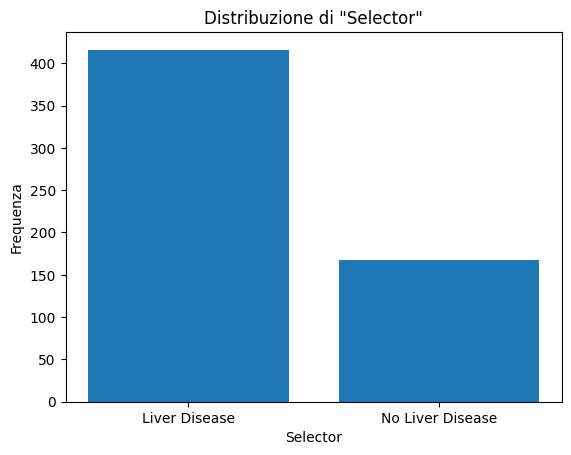

In [6]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [7]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'Sgot', 'TB', 'Sgpt', 'TP', 'ALB', 'Alkphos', 'Age', 'A/G Ratio', 'DB'}


In [8]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
df_encoded["Selector"] = df_encoded["Selector"].astype("category").cat.codes

In [9]:
df_encoded

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


In [10]:
df_encoded["Selector"].dtype

dtype('int8')

In [11]:
df_encoded["Gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [12]:
y = df_encoded["Selector"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [13]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [14]:
X_train.head()

,Gender,Sgot,TB,Sgpt,TP,ALB,Alkphos,Age,A/G Ratio,DB
401,1,236,7.3,44,6.8,1.6,92,50,0.30,3.7
395,1,20,0.8,24,6.3,3.2,140,45,1.00,0.2
3,1,20,1.0,14,6.8,3.4,182,58,1.00,0.4
102,1,45,0.9,36,6.9,4.2,224,17,1.55,0.2
175,1,31,0.8,43,7.3,4.0,198,31,1.20,0.2


In [15]:
y_train.head()

401    0
395    1
3      0
102    0
175    0
Name: Selector, dtype: int8

In [16]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [17]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[97 28]
 [32 18]]

Accuracy: 0.6571428571428571


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       129
           1       0.36      0.39      0.38        46

    accuracy                           0.66       175
   macro avg       0.57      0.57      0.57       175
weighted avg       0.67      0.66      0.66       175



### Miglioriamo l'albero

In [19]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [20]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[104  21]
 [ 41   9]]

Accuracy: 0.6457142857142857


In [21]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       145
           1       0.18      0.30      0.23        30

    accuracy                           0.65       175
   macro avg       0.51      0.51      0.50       175
weighted avg       0.72      0.65      0.68       175



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [23]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00204248 0.00204248 0.00210084 0.00222816 0.00222816
 0.00224673 0.00226244 0.00239398 0.00245098 0.0025531  0.00313982
 0.00326797 0.00367647 0.00367647 0.00371361 0.00420168 0.00420168
 0.00421713 0.00425099 0.0043573  0.00441176 0.00446429 0.0045098
 0.00465686 0.00485098 0.00499076 0.00526823 0.00597672 0.00640779
 0.00661765 0.00670041 0.0070028  0.00719375 0.00784032 0.00808945
 0.00837527 0.00932351 0.01163107 0.01228434 0.0142603  0.04182286]


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

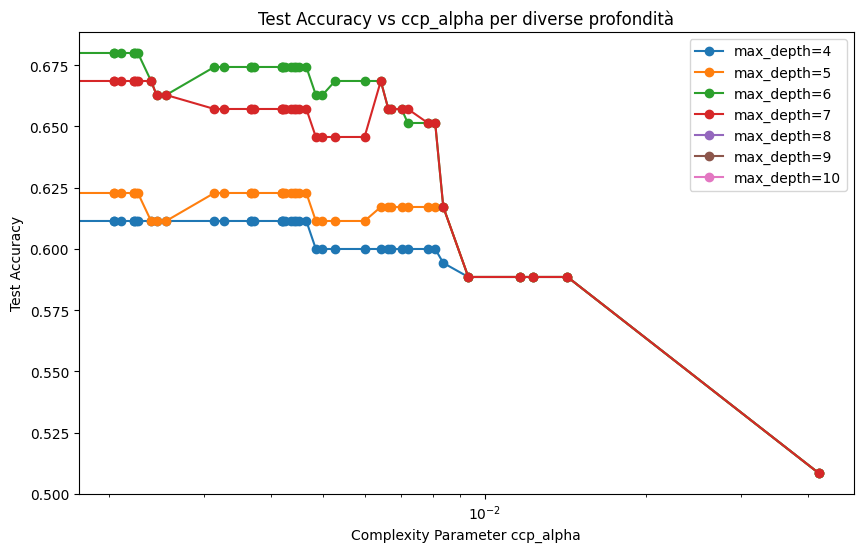

In [25]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [26]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 6
Miglior ccp_alpha: 0.0
Train accuracy: 0.7745098039215687
Test accuracy: 0.68


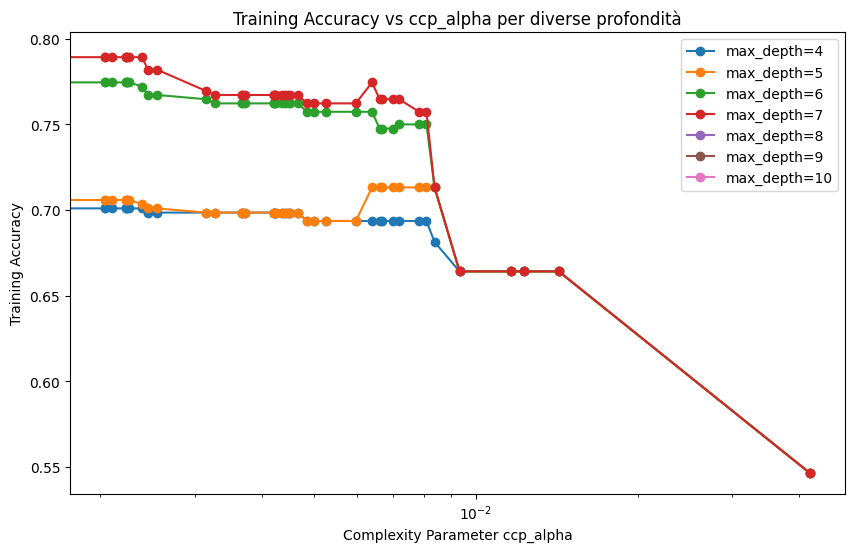

In [27]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [28]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7745098039215687
Accuracy test: 0.68


In [29]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[77 48]
 [ 8 42]]

Accuracy: 0.68


In [30]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.62      0.91      0.73        85
           1       0.84      0.47      0.60        90

    accuracy                           0.68       175
   macro avg       0.73      0.69      0.67       175
weighted avg       0.73      0.68      0.66       175



### diamo un occhiata con la balancedPrecision

In [31]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.62      0.73       125
           1       0.47      0.84      0.60        50

    accuracy                           0.68       175
   macro avg       0.69      0.73      0.67       175
weighted avg       0.78      0.68      0.70       175

Balanced accuracy: 0.728
[[77 48]
 [ 8 42]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [33]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             7
ccp_alpha                           0.0
class_weight               {0: 1, 1: 4}
weight_0                              1
weight_1                            4.0
train_accuracy                 0.776961
test_accuracy                  0.691429
train_balanced_accuracy        0.843643
test_balanced_accuracy            0.736
precision_class_1              0.477273
recall_class_1                     0.84
f1_class_1                     0.608696
macro_f1                       0.676989
weighted_f1                    0.706258
Name: 1391, dtype: object

Confusion matrix:
[[79 46]
 [ 8 42]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71    

In [34]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71       175



### Facciamo un ensemble a majority

In [35]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [36]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "test_accuracy": test_accuracy,
                    "test_balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [37]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.011631065783534442), 'class_weight': {0: 1, 1: 5}, 'weight_0': 1, 'weight_1': 5, 'test_accuracy': 0.6114285714285714, 'test_balanced_accuracy': 0.704, 'precision_class_1': 0.41818181818181815, 'recall_class_1': 0.92, 'f1_class_1': 0.575, 'macro_f1': 0.6085526315789473, 'weighted_f1': 0.6229323308270677}

Confusion matrix:
[[61 64]
 [ 4 46]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.49      0.64       125
           1       0.42      0.92      0.57        50

    accuracy                           0.61       175
   macro avg       0.68      0.70      0.61       175
weighted avg       0.79      0.61      0.62       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.575


In [38]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,test_accuracy,test_balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
566,5,0.011631,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
580,5,0.014260,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
573,5,0.012284,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
6,4,0.000000,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
48,4,0.002247,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
55,4,0.002262,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
34,4,0.002228,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
41,4,0.002228,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
62,4,0.002394,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925
69,4,0.002451,"{0: 1, 1: 5}",1,5.0,0.594286,0.698,0.408696,0.94,0.569697,0.592957,0.602925


In [39]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.94      0.49      0.64       125
           1       0.42      0.92      0.57        50

    accuracy                           0.61       175
   macro avg       0.68      0.70      0.61       175
weighted avg       0.79      0.61      0.62       175



### proviamo  a fare undersampling del dataframe

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=False
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "Selector"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [41]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [42]:
y_train.value_counts()

Selector
0    120
1    120
Name: count, dtype: int64

In [43]:
X_test.count()

Age          175
Gender       175
TB           175
DB           175
Alkphos      175
Sgpt         175
Sgot         175
TP           175
ALB          175
A/G Ratio    175
dtype: int64

In [44]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'test_accuracy': 0.6914285714285714, 'test_balanced_accuracy': 0.7755984042553192, 'precision_class_1': 0.4639175257731959, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.625, 'macro_f1': 0.6814320388349515, 'weighted_f1': 0.7075520110957004}

Confusion matrix:
[[76 52]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.625


In [45]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175



### Usiamo le random forests

In [46]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [47]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

In [48]:
# best_rf.fit(X_train, y_train)

# y_pred_test = best_rf.predict(X_test)
# print(classification_report(y_test, y_pred_test, zero_division=0))

In [49]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [50]:
# funzione per sporcare variabili categoriche
import numpy as np

def corrupt_rows_cat(df, col, frac=0.1, random_state=None):
    corrupt_df = df.copy()

    # Generatore casuale riproducibile
    rng = np.random.default_rng(random_state)

    # Recupero i valori univoci della colonna
    unique_values = corrupt_df[col].unique()

    # Se esiste un solo valore, non posso sostituirlo con qualcosa di diverso
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return corrupt_df

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(corrupt_df))

    # Scelgo righe casuali senza ripetizione
    indices_to_corrupt = rng.choice(
        corrupt_df.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Per ogni riga scelta, sostituisco il valore con un altro diverso
    for idx in indices_to_corrupt:
        current_value = corrupt_df.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        corrupt_df.at[idx, col] = rng.choice(pool_of_new_values)

    return corrupt_df

    #scelgo righe a caso
    #per scegliere righe a caso vado a indici:
        #creo un vettore degli indici (total_rows) lungo quando il df
        #faccio un ciclo lungo n_rows_to_corrupt
        #a ogni iterazione prendo una riga scelta a caso da total_rows e la metto nel vettore "rows_to_ruin"
        #elimino quella riga dal vettore total_row

#funzione per sporcare le variabili continue

import numpy as np

def corrupt_rows_cont(df, col, frac=0.1, noise_level=0.1, random_state=None):
    corrupt_df = df.copy()

    rng = np.random.default_rng(random_state)

    # Converto la colonna in float, così posso inserirci valori decimali
    corrupt_df[col] = corrupt_df[col].astype(float)

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(corrupt_df))

    # Scelgo gli indici delle righe da corrompere
    indices_to_corrupt = rng.choice(
        corrupt_df.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Deviazione standard della colonna
    std_col = corrupt_df[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return corrupt_df

    for idx in indices_to_corrupt:
        current_value = corrupt_df.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        corrupt_df.at[idx, col] = current_value + noise

    return corrupt_df




### mostro le variabili dalla più importante alla meno importante

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = df_encoded.drop(columns=["Selector"])
y = df_encoded["Selector"]

# scrivi qui le colonne categoriche
categoriche = ["Gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza
5       Sgpt    0.072161
6       Sgot    0.068853
0        Age    0.066943
2         TB    0.053878
3         DB    0.048560
4    Alkphos    0.028152
8        ALB    0.025456
9  A/G Ratio    0.018387
1     Gender    0.000000
7         TP    0.000000


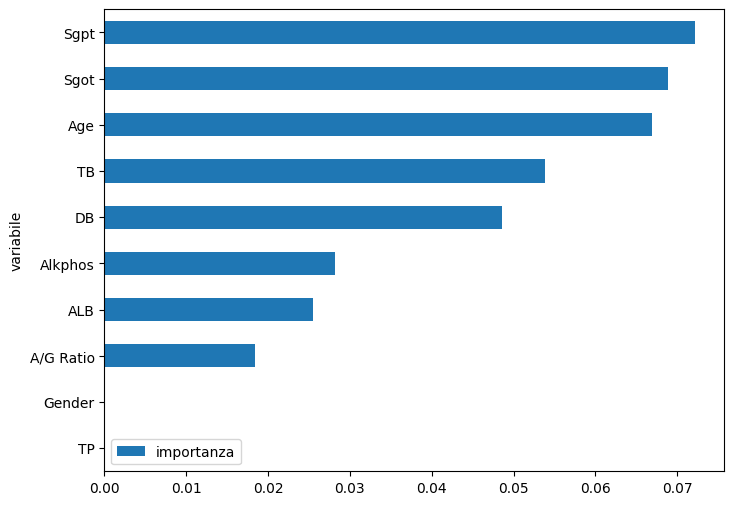

In [52]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [53]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [54]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [55]:
df_corrotto = corrupt_rows_cont(
    df_encoded,
    col="Sgpt",
    frac=0.2,
    noise_level=0.1,
    random_state=42
)

In [56]:
df_corrotto.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16.000000,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64.000000,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60.000000,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14.000000,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,-11.935505,59,7.3,2.4,0.40,0


In [57]:
#occhio, sto sovrascrivendo gli x_train e y_train puliti,non è un errore ma bisogna ricordarselo
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_corrotto,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [58]:
noise_training_results = [] #best_models, results_df, best_row, best_predictions 

noise_training_results= search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'test_accuracy': 0.6285714285714286, 'test_balanced_accuracy': 0.7124335106382979, 'precision_class_1': 0.4117647058823529, 'recall_class_1': 0.8936170212765957, 'f1_class_1': 0.5637583892617449, 'macro_f1': 0.6201876523423153, 'weighted_f1': 0.6463063398253222}

Confusion matrix:
[[68 60]
 [ 5 42]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.53      0.68       128
           1       0.41      0.89      0.56        47

    accuracy                           0.63       175
   macro avg       0.67      0.71      0.62       175
weighted avg       0.79      0.63      0.65       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.5637583892617449


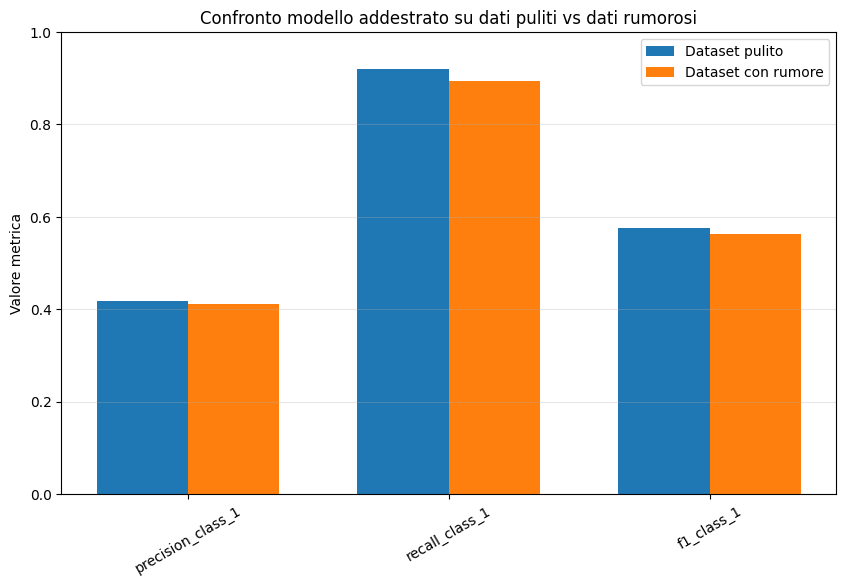

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def test_noise_progressivo(
    df,
    target_col,
    col_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):
    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if col_to_corrupt == target_col:
        raise ValueError("Non devi sporcare la colonna target.")

    # Capisco se la colonna è categorica oppure continua
    is_categorical = False

    # Caso 1: la colonna è stata dichiarata categorica dall'utente
    if col_to_corrupt in categorical_cols:
        is_categorical = True

    # Caso 2: dtype chiaramente categorico
    elif (
        df[col_to_corrupt].dtype == "object" or
        str(df[col_to_corrupt].dtype) == "category" or
        df[col_to_corrupt].dtype == "bool"
    ):
        is_categorical = True

    # Caso 3: colonna numerica intera con pochi valori diversi
    # Utile per colonne categoriche codificate come int8, int64, ecc.
    elif pd.api.types.is_integer_dtype(df[col_to_corrupt]):
        n_valori_unici = df[col_to_corrupt].nunique()

        if n_valori_unici <= max_unique_for_cat:
            is_categorical = True

    if is_categorical:
        print("Colonna riconosciuta come categorica:", col_to_corrupt)
    else:
        print("Colonna riconosciuta come continua:", col_to_corrupt)

    # Percentuali: 10%, 20%, ..., 100%
    percentuali_rumore = [
        0.1, 0.2, 0.3, 0.4, 0.5,
        0.6, 0.7, 0.8, 0.9, 1.0
    ]

    for frac in percentuali_rumore:
        print("Sto testando rumore al", int(frac * 100), "%")

        # 1. Creo dataset corrotto
        if is_categorical:
            df_corrotto = corrupt_rows_cat(
                df=df,
                col=col_to_corrupt,
                frac=frac,
                random_state=random_state
            )
        else:
            df_corrotto = corrupt_rows_cont(
                df=df,
                col=col_to_corrupt,
                frac=frac,
                noise_level=noise_level,
                random_state=random_state
            )

        # 2. Split train/test con undersampling
        X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
            df=df_corrotto,
            target_col=target_col,
            test_size=test_size,
            random_state=random_state,
            stratify=stratify
        )

        # 3. Addestramento e ricerca miglior modello
        training_results = search_best_ensemble_tree(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, best_predictions = training_results

        # 4. Converto best_row in dizionario
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row deve essere un dict, una Series o un DataFrame")

        # 5. Salvo informazioni sul rumore
        best_row_dict["colonna_sporcata"] = col_to_corrupt
        best_row_dict["tipo_colonna"] = "categorica" if is_categorical else "continua"
        best_row_dict["frac_rumore"] = frac
        best_row_dict["percentuale_rumore"] = int(frac * 100)

        risultati_finali.append(best_row_dict)

        # Salvo anche tutto, nel caso serva dopo
        risultati_completi[int(frac * 100)] = {
            "df_corrotto": df_corrotto,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions
        }

    # 6. Creo DataFrame riassuntivo
    risultati_df = pd.DataFrame(risultati_finali)

    # 7. Scelgo le metriche da graficare
    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    metriche_presenti = []

    for metrica in metriche_possibili:
        if metrica in risultati_df.columns:
            metriche_presenti.append(metrica)

    # 8. Grafico
    plt.figure(figsize=(10, 6))

    for metrica in metriche_presenti:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[metrica],
            marker="o",
            label=metrica
        )

    plt.xlabel("Percentuale di righe corrotte")
    plt.ylabel("Valore metrica")
    plt.title("Prestazioni del modello al crescere del rumore su " + col_to_corrupt)
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

Colonna riconosciuta come categorica: Gender
Sto testando rumore al 10 %
Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'test_accuracy': 0.6742857142857143, 'test_balanced_accuracy': 0.7638796542553192, 'precision_class_1': 0.45, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.6122448979591837, 'macro_f1': 0.6657283603096411, 'weighted_f1': 0.6904835628832814}

Confusion matrix:
[[73 55]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.57      0.72       128
           1       0.45      0.96      0.61        47

    accuracy                           0.67       175
   macro avg       0.71      0.76      0.67       175
weighted avg       0.83      0.67      0.69       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.6122448979591837
Sto testando rumore al 20 %
Migliore configurazione trovata:
{'max_de

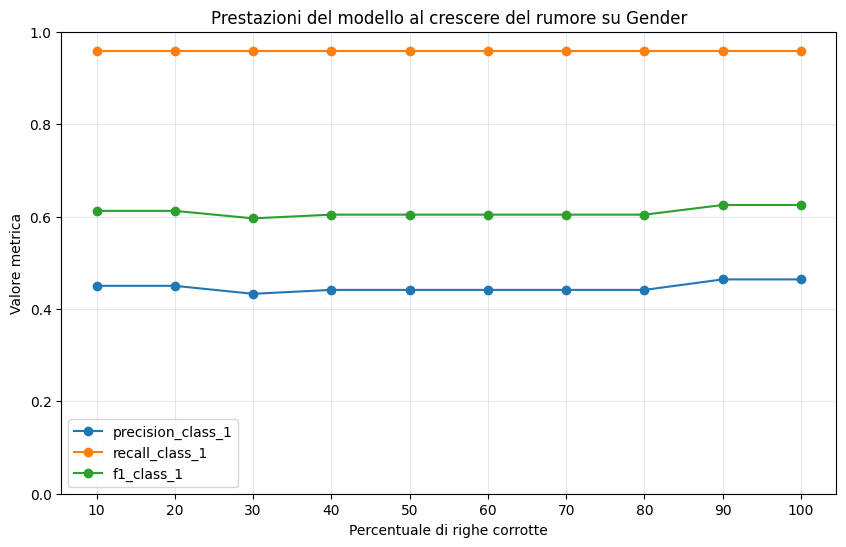

In [67]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    col_to_corrupt="Gender",
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_cont(
    df=df_encoded,
    target_col="Selector",
    col_to_corrupt="Gender",
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,test_accuracy,test_balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1,frac_rumore,percentuale_rumore
0,5,0.000000,"{0: 1, 1: 1.5}",1,1.5,0.680000,0.754322,0.452632,0.914894,0.605634,0.668202,0.697161,0.1,10
1,5,0.000000,"{0: 1, 1: 1.5}",1,1.5,0.628571,0.712434,0.411765,0.893617,0.563758,0.620188,0.646306,0.2,20
2,5,0.000000,"{0: 1, 1: 1.5}",1,1.5,0.640000,0.706782,0.416667,0.851064,0.559441,0.627546,0.659070,0.3,30
3,4,0.000000,"{0: 1, 1: 1.5}",1,1.5,0.617143,0.711353,0.405660,0.914894,0.562092,0.610995,0.633630,0.4,40
4,5,0.000000,"{0: 1, 1: 1}",1,1.0,0.645714,0.710688,0.421053,0.851064,0.563380,0.632652,0.664714,0.5,50
5,4,0.000000,"{0: 1, 1: 2}",1,2.0,0.628571,0.705701,0.410000,0.872340,0.557823,0.618813,0.647043,0.6,60
6,4,0.011631,"{0: 1, 1: 2}",1,2.0,0.651429,0.748255,0.432692,0.957447,0.596026,0.644747,0.667298,0.7,70
7,6,0.000000,"{0: 1, 1: 3}",1,3.0,0.628571,0.712434,0.411765,0.893617,0.563758,0.620188,0.646306,0.8,80
8,5,0.000000,"{0: 1, 1: 1.5}",1,1.5,0.622857,0.708527,0.407767,0.893617,0.560000,0.615000,0.640457,0.9,90
9,4,0.000000,"{0: 1, 1: 3}",1,3.0,0.634286,0.729804,0.419048,0.936170,0.578947,0.627858,0.650496,1.0,100
